In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from pathlib import Path
from tqdm import tqdm

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import GRU, Dense, RNN, GRUCell, Input

from tensorflow.keras.layers import RepeatVector, Concatenate

from tensorflow.keras.losses import BinaryCrossentropy, MeanSquaredError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.utils import plot_model

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv("training_df.csv")

df

,index,Unnamed: 0,time_UTC,observed_data,forecast_data,offset,x,y,station_id,time_UTC_dt
0,1,0.0,2022-09-25 01:00:00,2.560,2.315,-0.245,-73.710194,40.866222,1302250.0,0.0
1,3,1.0,2022-09-25 02:00:00,2.540,3.625,1.085,-73.710194,40.866222,1302250.0,60.0
2,5,2.0,2022-09-25 03:00:00,2.940,3.959,1.019,-73.710194,40.866222,1302250.0,120.0
3,7,3.0,2022-09-25 04:00:00,3.270,3.747,0.477,-73.710194,40.866222,1302250.0,180.0
4,9,4.0,2022-09-25 05:00:00,2.970,2.483,-0.487,-73.710194,40.866222,1302250.0,240.0
...,...,...,...,...,...,...,...,...,...,...
27383,83519,41759.0,2022-10-01 19:00:00,1.060,0.452,-0.608,-67.938500,18.089910,9759938.0,9720.0
27384,83521,41760.0,2022-10-01 20:00:00,1.063,0.410,-0.653,-67.938500,18.089910,9759938.0,9780.0
27385,83523,41761.0,2022-10-01 21:00:00,1.024,0.360,-0.664,-67.938500,18.089910,9759938.0,9840.0
27386,83525,41762.0,2022-10-01 22:00:00,0.981,0.293,-0.688,-67.938500,18.089910,9759938.0,9900.0


In [4]:
df = df[df['station_id'].isin([21989792.0, 219897993.0, 21989773.0, 8670870.0, 21989715.0])]

df.drop(['index','Unnamed: 0','forecast_data','observed_data','time_UTC_dt'], axis=1, inplace= True)

pivot_df = df.pivot_table(values='offset', index='time_UTC', columns='station_id', aggfunc='first')

pivot_df

station_id,8670870.0,21989715.0,21989773.0,21989792.0,219897993.0
time_UTC,,,,,
2022-09-25 01:00:00,-2.033,-1.801,-1.450,-0.997,-1.428
2022-09-25 02:00:00,-1.947,-2.332,-1.915,-1.127,-1.608
2022-09-25 03:00:00,-1.711,-2.396,-1.766,-0.387,-1.508
2022-09-25 04:00:00,-1.736,-1.517,-1.144,0.843,-1.053
2022-09-25 05:00:00,-1.393,-0.758,-0.249,2.523,-0.431
...,...,...,...,...,...
2022-10-01 19:00:00,-1.435,-1.340,-0.618,-0.666,-0.719
2022-10-01 20:00:00,-1.793,-1.463,-0.895,0.186,-0.970
2022-10-01 21:00:00,-1.730,-0.930,-0.511,1.506,-0.680


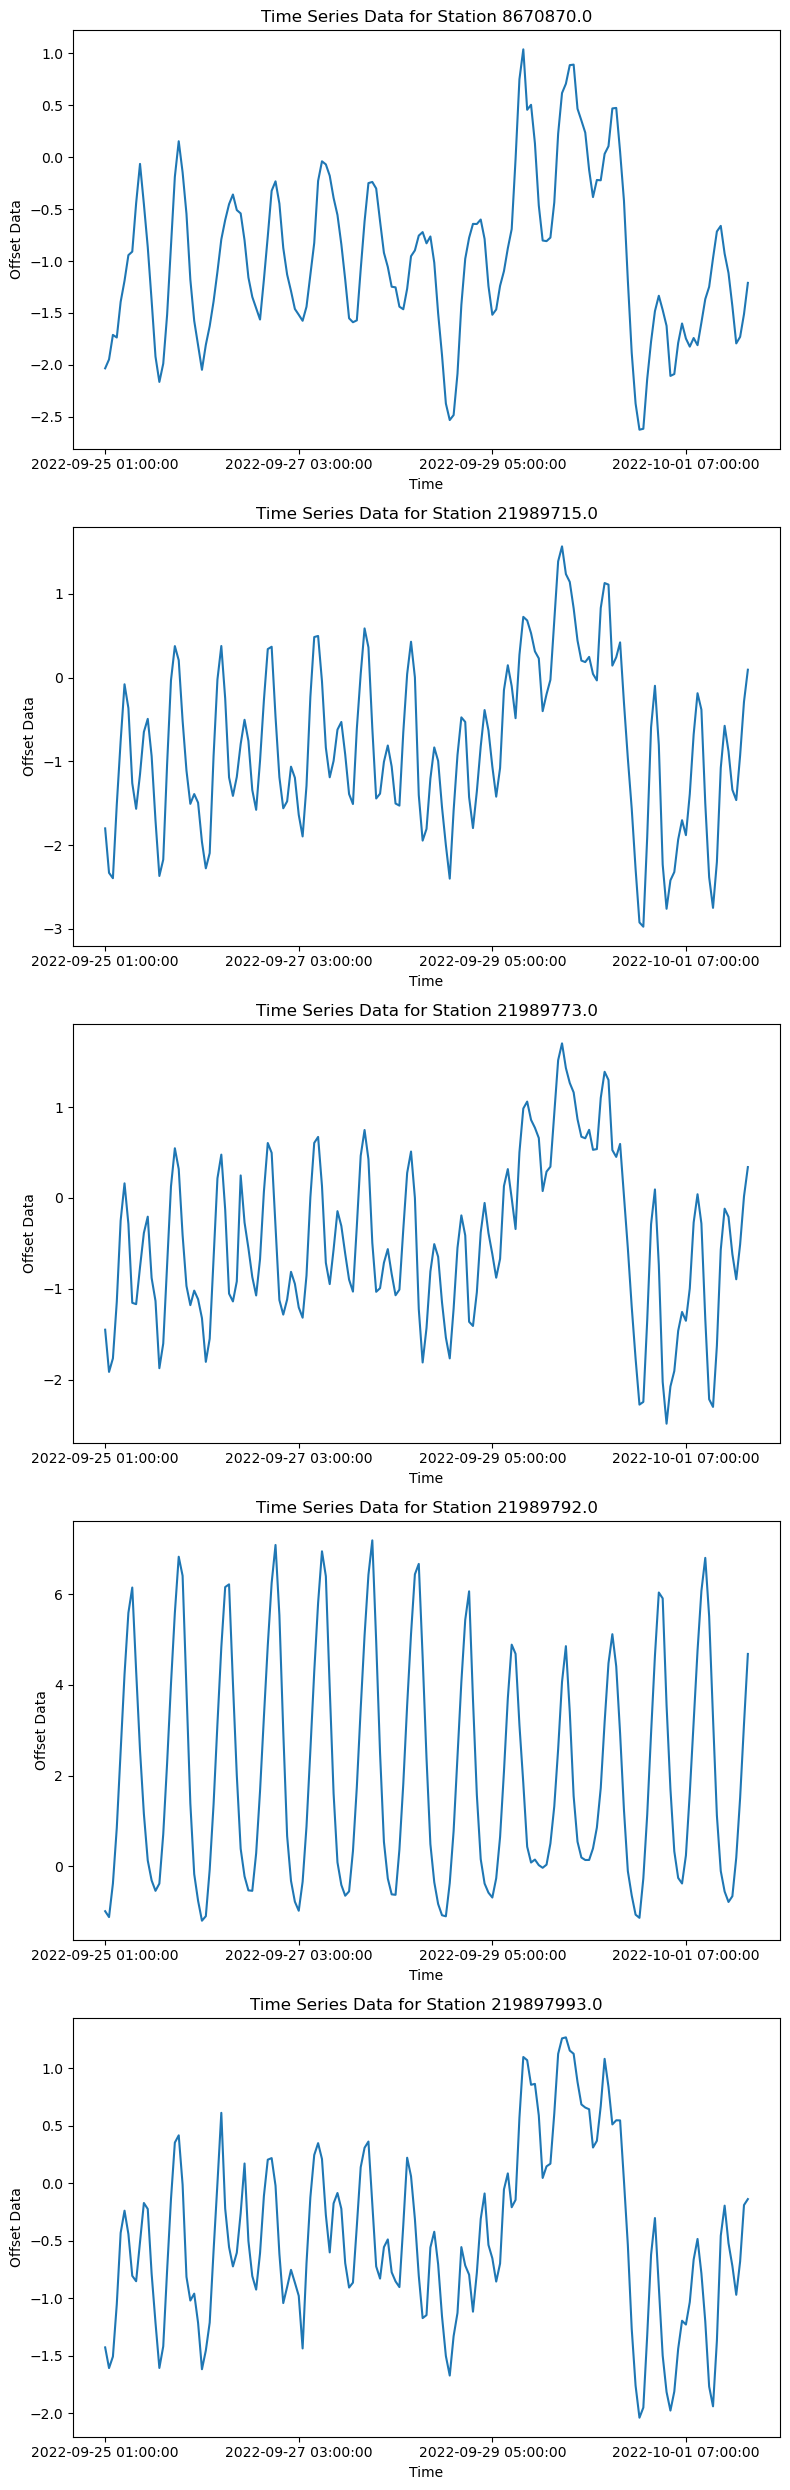

In [5]:
from matplotlib.ticker import MaxNLocator

fig, axs = plt.subplots(nrows=len(pivot_df.columns), figsize=(8, 5*len(pivot_df.columns)))

for i, col in enumerate(pivot_df.columns):
    axs[i].plot(pivot_df.index, pivot_df[col], label=f'Station {col}')
    axs[i].set_xlabel('Time')
    axs[i].set_ylabel('Offset Data')
    axs[i].set_title(f'Time Series Data for Station {col}')

    axs[i].xaxis.set_major_locator(MaxNLocator(nbins=4))

plt.tight_layout()
plt.show()

# Prepare Data

In [6]:
seq_len = 12
batch_size = 32

In [7]:
coords_df = df[['station_id', 'x', 'y']].drop_duplicates()

coords_df

,station_id,x,y
5010,21989715.0,-81.129279,32.115761
5177,21989773.0,-81.081223,32.081041
5344,21989792.0,-81.130000,32.165833
5511,219897993.0,-81.006944,32.102370
18537,8670870.0,-80.901700,32.034612


In [8]:
coords_df

,station_id,x,y
5010,21989715.0,-81.129279,32.115761
5177,21989773.0,-81.081223,32.081041
5344,21989792.0,-81.130000,32.165833
5511,219897993.0,-81.006944,32.102370
18537,8670870.0,-80.901700,32.034612


In [9]:
scaler_coords = MinMaxScaler()

# Normalize the coordinates dataframe
coords_df[['x', 'y']] = scaler_coords.fit_transform(coords_df[['x', 'y']])
coords_df['coords'] = list(zip(coords_df['x'], coords_df['y']))

scaler_ts = MinMaxScaler()

# Create the scaled data dataframe from which we will create the rolling window sequences
scaled_df = scaler_ts.fit_transform(pivot_df)
scaled_df = pd.DataFrame(scaled_df, columns=pivot_df.columns, index=pivot_df.index)

In [10]:
window_df = pd.DataFrame(columns=scaled_df.columns)

for column in scaled_df.columns:
    window_sequences = []
    
    for i in range(len(scaled_df) - seq_len + 1):
        window_sequence = scaled_df[column].iloc[i:i + seq_len].tolist()
        window_sequences.append(window_sequence)
    
    window_df[column] = window_sequences

window_df

station_id,8670870.0,21989715.0,21989773.0,21989792.0,219897993.0
0,"[0.1613431613431613, 0.18482118482118748, 0.24...","[0.25847644209599296, 0.14156759136944086, 0.1...","[0.24719369476952469, 0.13613565798901356, 0.1...","[0.02499404903594278, 0.009521542489883378, 0....","[0.18483841739655693, 0.13047417698580482, 0.1..."
1,"[0.18482118482118748, 0.2492492492492519, 0.24...","[0.14156759136944086, 0.12747688243064736, 0.3...","[0.13613565798901356, 0.17172199665631716, 0.3...","[0.009521542489883378, 0.09759581052130338, 0....","[0.13047417698580482, 0.160676532769556, 0.298..."
2,"[0.2492492492492519, 0.24242424242424238, 0.33...","[0.12747688243064736, 0.32100396301188905, 0.4...","[0.17172199665631716, 0.32027704800573203, 0.5...","[0.09759581052130338, 0.2439895263032602, 0.44...","[0.160676532769556, 0.29809725158562367, 0.485..."
3,"[0.24242424242424238, 0.336063336063336, 0.391...","[0.32100396301188905, 0.48811096433289325, 0.6...","[0.32027704800573203, 0.5340339144972537, 0.63...","[0.2439895263032602, 0.4439419185908099, 0.647...","[0.29809725158562367, 0.48595590456055604, 0.5..."
4,"[0.336063336063336, 0.39148239148239145, 0.458...","[0.48811096433289325, 0.6373844121532365, 0.57...","[0.5340339144972537, 0.631956054454263, 0.5251...","[0.4439419185908099, 0.6474648893120681, 0.809...","[0.48595590456055604, 0.5442464512231954, 0.48..."
...,...,...,...,...,...
151,"[0.21840021840022106, 0.2410592410592437, 0.22...","[0.34896521356230736, 0.5055041831792164, 0.61...","[0.3558633866730356, 0.5290183902555529, 0.603...","[0.3358724113306348, 0.5228517019757195, 0.709...","[0.30413772274237394, 0.4158864391422534, 0.46..."
152,"[0.2410592410592437, 0.22222222222222487, 0.28...","[0.5055041831792164, 0.6138265081461911, 0.570...","[0.5290183902555529, 0.6032959159302603, 0.526...","[0.5228517019757195, 0.7098309926208042, 0.867...","[0.4158864391422534, 0.4699486559951676, 0.379..."
153,"[0.22222222222222487, 0.2817362817362817, 0.34...","[0.6138265081461911, 0.570673712021136, 0.3240...","[0.6032959159302603, 0.5261523764031526, 0.275...","[0.7098309926208042, 0.8670554629850022, 0.953...","[0.4699486559951676, 0.37934158864391454, 0.25..."
154,"[0.2817362817362817, 0.3434343434343461, 0.375...","[0.570673712021136, 0.3240863055922523, 0.1301...","[0.5261523764031526, 0.27561499880582757, 0.06...","[0.8670554629850022, 0.9539395382051892, 0.800...","[0.37934158864391454, 0.25279371790999994, 0.0..."


In [11]:
df= pivot_df

In [12]:
coords_array = coords_df[['x', 'y']].values

coords_array

array([[0.00315856, 0.61841128],
       [0.21365309, 0.3538235 ],
       [0.        , 1.        ],
       [0.53900832, 0.51636422],
       [1.        , 0.        ]])

In [13]:
coords_array[1]

array([0.21365309, 0.3538235 ])

## TimeGAN Components

In [14]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Flatten, Input, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError, BinaryCrossentropy

In [15]:
input_shape = (12, 1)
static_dim = 2

temp_embedder = Sequential([
    Input(shape=input_shape),
    GRU(units=64, return_sequences=True),
    GRU(units=32, return_sequences=True),
    Dense(units=32, activation='tanh'),
    Flatten(),
    Dense(units=24, activation='linear')
])

static_embedder = Dense(4, activation='sigmoid', name='StaticEmbedding') # was 32

def embedder(X, S):
    e_outputs = temp_embedder(X)
    HS = static_embedder(S)
    h_inputs = tf.concat([e_outputs, HS], axis=-1)
    HT = Dense(12, activation='sigmoid', name='EmbedderOutput')(h_inputs) # was 128
    return HT, HS

recovery_temp = Sequential([
    Input(shape=(1, 12)),
    GRU(units=64, return_sequences=True), 
    GRU(units = 48, return_sequences=False),
    Dense(units = 24, activation='sigmoid') # was 128
])

recovery_static = Dense(static_dim, activation='sigmoid', name='StaticRecovery')

def recovery(H, S):
    H_reshaped = tf.expand_dims(H, axis=1)
    r_outputs = recovery_temp(H_reshaped) 
    XT_tilde = Dense(12, activation='sigmoid', name='RecoveryOutput')(r_outputs)
    XS_tilde = recovery_static(S)
    return XT_tilde, XS_tilde

In [16]:
temp_embedder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 12, 64)            12864     
                                                                 
 gru_1 (GRU)                 (None, 12, 32)            9408      
                                                                 
 dense (Dense)               (None, 12, 32)            1056      
                                                                 
 flatten (Flatten)           (None, 384)               0         
                                                                 
 dense_1 (Dense)             (None, 24)                9240      
                                                                 
Total params: 32,568
Trainable params: 32,568
Non-trainable params: 0
_________________________________________________________________


In [17]:
recovery_temp.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_2 (GRU)                 (None, 1, 64)             14976     
                                                                 
 gru_3 (GRU)                 (None, 48)                16416     
                                                                 
 dense_2 (Dense)             (None, 24)                1176      
                                                                 
Total params: 32,568
Trainable params: 32,568
Non-trainable params: 0
_________________________________________________________________


## TimeGAN Training

In [18]:
train_steps = 1000
gamma = 1

mse = MeanSquaredError()
bce = BinaryCrossentropy()

## Autoencoder Training

In [19]:
X = Input(shape=(12, 1), name='RealData')
S = Input(shape=(2,), name='StaticData')

H, HS = embedder(X, S)
X_tilde, S_tilde = recovery(H, HS)

autoencoder = Model(inputs=[X, S],
                    outputs=[X_tilde, S_tilde],
                    name='Autoencoder')

autoencoder_optimizer = Adam()
autoencoder.compile(optimizer=autoencoder_optimizer, loss=mse)

autoencoder.summary()

Model: "Autoencoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 RealData (InputLayer)          [(None, 12, 1)]      0           []                               
                                                                                                  
 StaticData (InputLayer)        [(None, 2)]          0           []                               
                                                                                                  
 sequential (Sequential)        (None, 24)           32568       ['RealData[0][0]']               
                                                                                                  
 StaticEmbedding (Dense)        (None, 4)            12          ['StaticData[0][0]']             
                                                                                        

In [20]:
@tf.function
def train_autoencoder_init(x, s):
    with tf.GradientTape() as tape:
        x_tilde, s_tilde = autoencoder([x, s])
        embedding_loss_t0 = mse(x, x_tilde)
        static_loss_t0 = mse(s, s_tilde)
        e_loss_0 = 10 * tf.sqrt(embedding_loss_t0 + static_loss_t0)
        
    var_list = autoencoder.trainable_variables
    gradients = tape.gradient(e_loss_0, var_list)
    autoencoder_optimizer.apply_gradients(zip(gradients, var_list))
    
    return tf.sqrt(embedding_loss_t0), tf.sqrt(static_loss_t0)

autoencoder_static_loss_hist = []
autoencoder_temporal_loss_hist = []
autoencoder_training_history = []

for step in tqdm(range(100)): # train steps
    j=0
    for col in window_df.columns:  # Iterate over columns (stations)  
        for i in range(len(window_df)):  # Iterate over rows (time series sequences)
            X_ = np.expand_dims(window_df.iloc[i][col], axis=-1)  # Reshape to (seq_len, 1)
            X_ = np.transpose(X_)
            S_ = coords_array[j].reshape(1, 2)
            step_e_loss_t0, step_stat_loss = train_autoencoder_init(X_, S_)
        j+=1
    
    if step % 5 == 0:
        autoencoder_training_history.append(step_e_loss_t0.numpy())
        autoencoder_static_loss_hist.append(step_stat_loss.numpy())
    
    if step % 5 == 0:
        print(f"Step {step}, Loss: {step_e_loss_t0.numpy()}")

  1%|▊                                                                                | 1/100 [00:08<14:42,  8.91s/it]

Step 0, Loss: 0.20994386076927185


  6%|████▊                                                                            | 6/100 [00:37<09:13,  5.89s/it]

Step 5, Loss: 0.20635296404361725


 11%|████████▊                                                                       | 11/100 [01:08<09:03,  6.10s/it]

...

 91%|████████████████████████████████████████████████████████████████████████▊       | 91/100 [09:08<00:44,  4.92s/it]

Step 90, Loss: 0.197792649269104


 96%|████████████████████████████████████████████████████████████████████████████▊   | 96/100 [09:32<00:19,  4.87s/it]

Step 95, Loss: 0.1977912187576294


100%|███████████████████████████████████████████████████████████████████████████████| 100/100 [09:52<00:00,  5.92s/it]


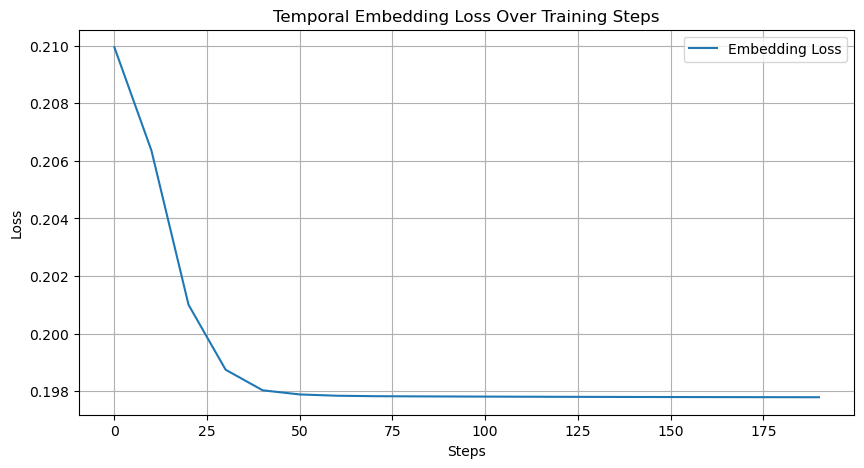

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(range(0, len(autoencoder_training_history)*10, 10), autoencoder_training_history, label='Embedding Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Temporal Embedding Loss Over Training Steps')
plt.legend()
plt.grid(True)
plt.show()

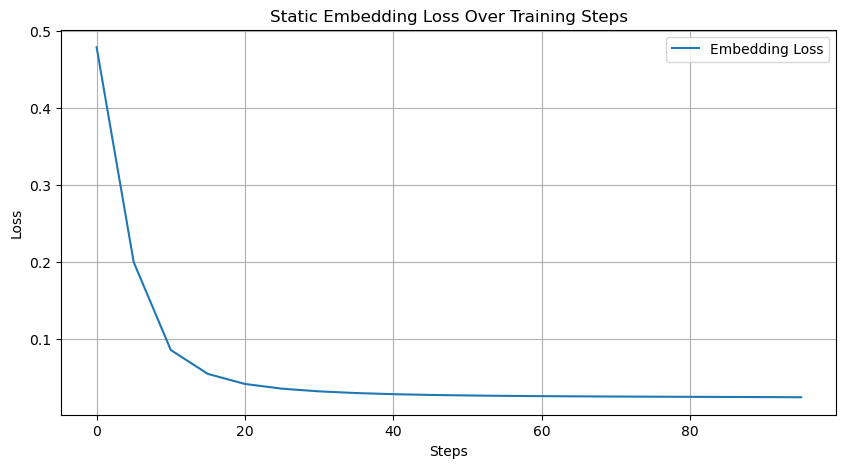

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(range(0, len(autoencoder_static_loss_hist)*5, 5), autoencoder_static_loss_hist, label='Embedding Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Static Embedding Loss Over Training Steps')
plt.legend()
plt.grid(True)
plt.show()

## Phase 2: Supervised training

### Supervisor Model

In [23]:
temp_supervisor = Sequential([
    Input(shape=(1, 12)), # 12 is the output of the embedder
    GRU(units=64, return_sequences = False),
#     GRU(units=32, return_sequences=False),
#    Dense(units=32, activation='tanh'), # Remove
    Dense(units=12, activation='linear')
])

static_supervisor = Dense(4, activation='sigmoid') # 4 is the output of the static embedder

def supervisor(X, S):
    sup_outputs = temp_supervisor(X)
    HS_sup = static_supervisor(S)
    sup_inputs = tf.concat([sup_outputs, HS_sup], axis=-1)
    HT_sup = Dense(12, activation='sigmoid', name='SupervisorOutput')(sup_inputs)
    
    return HT_sup, HS_sup #X, S, are the embeddings? # Removed

#temp_supervisor.summary()

In [24]:
# ht, hs = embedder(X, S)
# ht_1 = tf.reshape(ht, (1, 1, 12))

ht = Input(shape=(1,12), name="SupervisorTempInput")
hs = Input(shape=(4,), name= "SupervisorStaticInput")

sup_temp_emb, sup_static_emb = supervisor(ht, hs) # Removed embedded_t_inputs, embedded_s_inputs, 

supervisor_model = Model(inputs=[ht, hs],
                    outputs=[sup_temp_emb, sup_static_emb],
                    name='Supervisor')

supervisor_optimizer = Adam()
supervisor_model.compile(optimizer = supervisor_optimizer, loss=mse)

supervisor_model.summary()

Model: "Supervisor"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 SupervisorTempInput (InputLaye  [(None, 1, 12)]     0           []                               
 r)                                                                                               
                                                                                                  
 SupervisorStaticInput (InputLa  [(None, 4)]         0           []                               
 yer)                                                                                             
                                                                                                  
 sequential_2 (Sequential)      (None, 12)           15756       ['SupervisorTempInput[0][0]']    
                                                                                         

In [25]:
@tf.function
def train_supervisor(x, s):
    with tf.GradientTape() as tape:
        ht_hat_supervised, hs_hat_supervised = supervisor_model([x, s])
        gt_loss_s = mse(x, ht_hat_supervised)
        gs_loss_s = mse(s, hs_hat_supervised)
        g_loss_s = (gt_loss_s + gs_loss_s)

    var_list = supervisor_model.trainable_variables
    gradients = tape.gradient(g_loss_s, var_list)
    supervisor_optimizer.apply_gradients(zip(gradients, var_list))
    
    return tf.sqrt(gt_loss_s), tf.sqrt(gs_loss_s)

supervised_temp_training_history = []
supervised_static_training_history = []

for step in tqdm(range(100)): # Train Steps
    j=0
    for col in window_df.columns:  # Iterate over columns (stations)  
        for i in range(len(window_df)):  # Iterate over rows (time series sequences)
            X_ = np.expand_dims(window_df.iloc[i][col], axis=-1)  # Reshape to (seq_len, 1)
            X_ = np.transpose(X_)
            S_ = coords_array[j].reshape(1, 2)
            ht, hs = embedder(X_, S_)
            ht_1 = tf.reshape(ht, (1, 1, 12))
            step_gt_loss_s, step_gs_loss_s = train_supervisor(ht_1, hs)
        j+=1
    
    if step % 5 == 0: # Change
        supervised_temp_training_history.append(step_gt_loss_s.numpy())
        supervised_static_training_history.append(step_gs_loss_s.numpy())
    
    if step % 5 == 0: # Change
        print(f"Step {step}, Loss: {step_gt_loss_s.numpy()}")

  1%|▊                                                                                | 1/100 [00:27<45:51, 27.80s/it]

Step 0, Loss: 0.2182157188653946


  6%|████▊                                                                            | 6/100 [02:39<41:31, 26.50s/it]

Step 5, Loss: 0.04413294047117233


 11%|████████▊                                                                       | 11/100 [04:51<39:05, 26.35s/it]

...

 91%|████████████████████████████████████████████████████████████████████████▊       | 91/100 [39:56<03:56, 26.28s/it]

Step 90, Loss: 0.02929076738655567


 96%|████████████████████████████████████████████████████████████████████████████▊   | 96/100 [42:06<01:44, 26.16s/it]

Step 95, Loss: 0.04373347386717796


100%|███████████████████████████████████████████████████████████████████████████████| 100/100 [43:51<00:00, 26.32s/it]


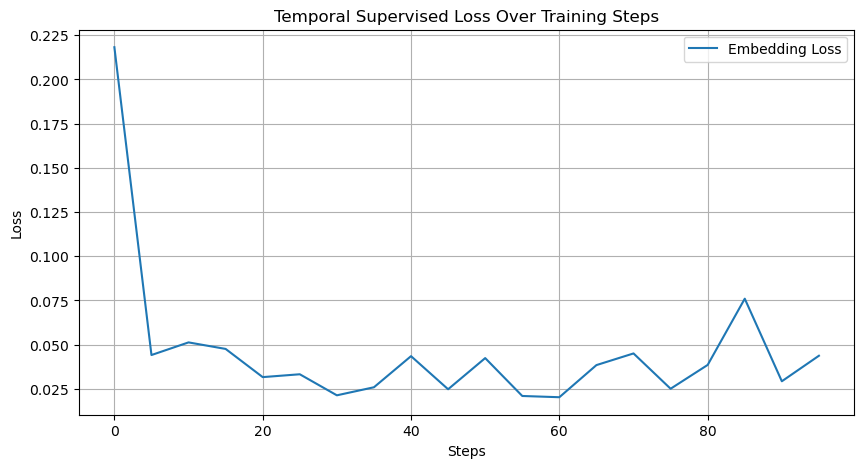

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(range(0, len(supervised_temp_training_history)*5, 5), supervised_temp_training_history, label='Embedding Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Temporal Supervised Loss Over Training Steps')
plt.legend()
plt.grid(True)
plt.show()

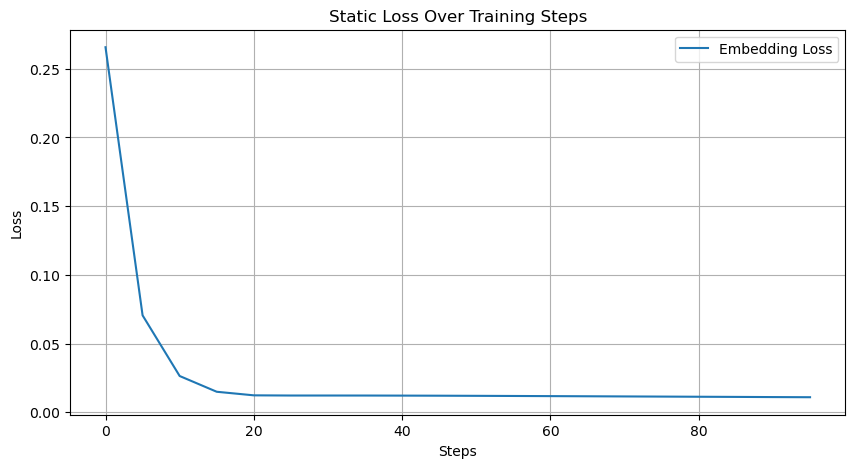

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(range(0, len(supervised_static_training_history)*5, 5), supervised_static_training_history, label='Embedding Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Static Loss Over Training Steps')
plt.legend()
plt.grid(True)
plt.show()

## Phase 3: Joint Training

### Generator - Discriminator Models

In [28]:
# Making the data from which the Generator takes input

def make_temp_random_data():
    while True:
        yield np.random.uniform(low=0, high=1, size=(seq_len,))
        
def make_static_random_data():
    while True:
        yield np.random.uniform(low=0, high=1, size=(2,))
        
random_temp_series = iter(tf.data.Dataset
                     .from_generator(make_temp_random_data, output_types=tf.float32)
                     .batch(1)
                     .repeat())

random_static_series = iter(tf.data.Dataset
                     .from_generator(make_static_random_data, output_types=tf.float32)
                     .batch(1)
                     .repeat())

In [29]:
from tensorflow.keras.layers import Bidirectional

# Generator must have the same complexity as the embedder
temp_generator = Sequential([
    Input(shape=input_shape),
    GRU(units=64, return_sequences=True),
    GRU(units=32, return_sequences=True),
    Dense(units=32, activation='tanh'),
    Flatten(),
    Dense(units=12, activation='linear') # Temporal Embeddings Length, not 24 as we are not concatenating...
])

static_generator = Dense(4, activation='sigmoid', name='StaticGenerator') # Static Embeddings Length

def generator_model(ZT, ZS):
    g_outputs = temp_generator(ZT)
    g_static = static_generator(ZS)
    
    #g_inputs = tf.concat([g_outputs, g_static], axis=-1)    # Maybe should be added? As we want to extrapolate the data, so 
                                                             # generator may have to understand the relation... or is it
                                                             # fulfilled by the supervisor?
    #g_temporal = Dense( seq_length , activation='sigmoid', name='GeneratorOutput')(g_inputs) # Sequence Length
    
    return g_outputs, g_static

# temp_discriminator = Sequential([
#          Bidirectional(GRU(32, return_sequences=True)),
#          Bidirectional(GRU(16, return_sequences=False)),
#          Dense(1, activation='sigmoid')
# ])

# static_discriminator = Dense(1, activation='sigmoid', name='StaticRecovery')

discriminator_network = Sequential([
         Bidirectional(GRU(32, return_sequences=True)),
         Bidirectional(GRU(16, return_sequences=False)),
         Dense(1, activation='sigmoid')
])

def discriminator_model(T_input, S_input):
    d_inputs = tf.concat([T_input, S_input], axis=-1)
    d_inputs = tf.reshape(d_inputs, (1, 1, 16))
    Y = discriminator_network(d_inputs)
    
    return Y

temp_generator.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_5 (GRU)                 (None, 12, 64)            12864     
                                                                 
 gru_6 (GRU)                 (None, 12, 32)            9408      
                                                                 
 dense_5 (Dense)             (None, 12, 32)            1056      
                                                                 
 flatten_1 (Flatten)         (None, 384)               0         
                                                                 
 dense_6 (Dense)             (None, 12)                4620      
                                                                 
Total params: 27,948
Trainable params: 27,948
Non-trainable params: 0
_________________________________________________________________


In [30]:
Z = Input(shape=(12, 1), name='RandomTemp') # Change according to window length 
ZS = Input(shape=(2,), name='RandomStatic')

g_outputs, g_static = generator_model(Z, ZS)

generator = Model(inputs=[Z, ZS],
                    outputs=[g_outputs, g_static],
                    name='Generator')

Dt_input = Input(shape=(12, ), name='DiscTempInput')
Ds_input = Input(shape=(4, ), name='DiscStaticInput')

Y_fake = discriminator_model(Dt_input, Ds_input)

discriminator = Model(inputs=[Dt_input, Ds_input],
                      outputs= Y_fake,
                      name='Discriminator'
                     )

generator.summary()

Model: "Generator"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 RandomTemp (InputLayer)        [(None, 12, 1)]      0           []                               
                                                                                                  
 RandomStatic (InputLayer)      [(None, 2)]          0           []                               
                                                                                                  
 sequential_3 (Sequential)      (None, 12)           27948       ['RandomTemp[0][0]']             
                                                                                                  
 StaticGenerator (Dense)        (None, 4)            12          ['RandomStatic[0][0]']           
                                                                                          

In [31]:
# Adversarial Supervised Model (Supervisor & Discriminator)

E_t_hat, E_s_hat = generator([Z, ZS])
E_t_hat_reshaped = tf.reshape(E_t_hat, (1, 1, 12))

H_t_hat, H_s_hat = supervisor_model([E_t_hat_reshaped, E_s_hat])

Y_fake = discriminator([H_t_hat, H_s_hat])

adversarial_supervised = Model(inputs=[Z, ZS],
                               outputs=Y_fake,
                               name='AdversarialNetSupervised')

adversarial_supervised.summary()

Model: "AdversarialNetSupervised"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 RandomTemp (InputLayer)        [(None, 12, 1)]      0           []                               
                                                                                                  
 RandomStatic (InputLayer)      [(None, 2)]          0           []                               
                                                                                                  
 Generator (Functional)         [(None, 12),         27960       ['RandomTemp[0][0]',             
                                 (None, 4)]                       'RandomStatic[0][0]']           
                                                                                                  
 tf.reshape_1 (TFOpLambda)      (1, 1, 12)           0           ['Generato

In [32]:
# Adversarial Unsupervised Model (Generator & Discriminator)
Y_fake_e = discriminator([E_t_hat, E_s_hat])

adversarial_emb = Model(inputs=[Z, ZS],
                    outputs=Y_fake_e,
                    name='AdversarialNetUnsupervised')

adversarial_emb.summary()

Model: "AdversarialNetUnsupervised"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 RandomTemp (InputLayer)        [(None, 12, 1)]      0           []                               
                                                                                                  
 RandomStatic (InputLayer)      [(None, 2)]          0           []                               
                                                                                                  
 Generator (Functional)         [(None, 12),         27960       ['RandomTemp[0][0]',             
                                 (None, 4)]                       'RandomStatic[0][0]']           
                                                                                                  
 Discriminator (Functional)     (1, 1)               17505       ['Genera

In [33]:
# Real data Discriminator (Discriminator & Embedder)

Y_real = discriminator([H, HS]) # Results of the Embedder

discriminator_real = Model(inputs=[X,S],
                            outputs=Y_real,
                            name='DiscriminatorReal')

discriminator_real.summary()

Model: "DiscriminatorReal"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 RealData (InputLayer)          [(None, 12, 1)]      0           []                               
                                                                                                  
 StaticData (InputLayer)        [(None, 2)]          0           []                               
                                                                                                  
 sequential (Sequential)        (None, 24)           32568       ['RealData[0][0]']               
                                                                                                  
 StaticEmbedding (Dense)        (None, 4)            12          ['StaticData[0][0]']             
                                                                                  

## DATA GENERATION

In [34]:
# Synthetic Data Generator (Generator - Supervisor - Recovery)

Xt_hat, Xs_hat = recovery(H_t_hat, H_s_hat)

synthetic_data = Model(inputs=[Z, ZS],
                       outputs=[Xt_hat, Xs_hat],
                       name='SyntheticData')

synthetic_data.summary()

Model: "SyntheticData"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 RandomTemp (InputLayer)        [(None, 12, 1)]      0           []                               
                                                                                                  
 RandomStatic (InputLayer)      [(None, 2)]          0           []                               
                                                                                                  
 Generator (Functional)         [(None, 12),         27960       ['RandomTemp[0][0]',             
                                 (None, 4)]                       'RandomStatic[0][0]']           
                                                                                                  
 tf.reshape_1 (TFOpLambda)      (1, 1, 12)           0           ['Generator[0][0]']  

### Training Steps

In [35]:
generator_optimizer = Adam()
discriminator_optimizer = Adam()
embedding_optimizer = Adam()

In [36]:
# Loss function to monitor the distribution of the Generator's temporal data

def get_generator_moment_loss(y_true, y_pred):
    
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    y_true_mean, y_true_var = tf.nn.moments(x=y_true, axes=[0])
    y_pred_mean, y_pred_var = tf.nn.moments(x=y_pred, axes=[0])
    g_loss_mean = tf.reduce_mean(tf.abs(y_true_mean - y_pred_mean))
    g_loss_var = tf.reduce_mean(tf.abs(tf.sqrt(y_true_var + 1e-6) - tf.sqrt(y_pred_var + 1e-6)))
    
    return g_loss_mean + g_loss_var

In [37]:
# Weight for the unsupervised fake loss
gamma = 1

#############################################################

# discriminator loss: loss_real, loss_fake, loss_fake_e
@tf.function
def get_discriminator_loss(x, s, z, zs):
    
    # real loss
    y_real = discriminator_real([x, s])
    discriminator_loss_real = bce(y_true=tf.ones_like(y_real),
                                  y_pred=y_real)
    
    # supervised fake loss
    y_fake = adversarial_supervised([z, zs])
    discriminator_loss_fake = bce(y_true=tf.zeros_like(y_fake),
                                  y_pred=y_fake)
    
    # unsupervised fake loss
    y_fake_e = adversarial_emb([z, zs])
    discriminator_loss_fake_e = bce(y_true=tf.zeros_like(y_fake_e),
                                    y_pred=y_fake_e)
    
    return (discriminator_loss_real +
            discriminator_loss_fake +
            gamma * discriminator_loss_fake_e)

In [38]:
### Generator Training Step

# Weights for generator losses
supervised_gen_loss_weight= 100 # Was 1 with all the generator's losses having similar weights, gave worse results in
                              # terms of distribution.

distribution_loss_weight = 1
##########################################################################

@tf.function
def train_generator(x, ht_1, hs, z, zs): # ht_1, hs, the results of the embedder, are given as input as they were creating
                                            # errors when created inside the tf.function
    with tf.GradientTape() as tape:
        # adversarial semi-supervised loss (Generator + Supervisor)
        y_fake = adversarial_supervised([z, zs])
        generator_loss_unsupervised = bce(y_true=tf.ones_like(y_fake),
                                          y_pred=y_fake)
        
        # adversarial unsupervised loss (Generator)
        y_fake_e = adversarial_emb([z, zs])
        generator_loss_unsupervised_e = bce(y_true=tf.ones_like(y_fake_e),
                                            y_pred=y_fake_e)
        
        # adversarial supervised loss (Embedder + Supervisor)
        
        ht_hat_supervised, hs_hat_supervised = supervisor_model([ht_1, hs])
        generator_temp_loss_supervised = mse(ht_1, ht_hat_supervised)
        generator_static_loss_supervised = mse(hs, hs_hat_supervised)

        # distribution loss
        #######################################################################
        xt_hat, xs_hat = synthetic_data([z, zs])
        
        generator_moment_loss = get_generator_moment_loss(x, xt_hat)

        generator_loss = (generator_loss_unsupervised +
                          generator_loss_unsupervised_e +
                          supervised_gen_loss_weight * tf.sqrt(generator_temp_loss_supervised + generator_static_loss_supervised) +
                          distribution_loss_weight * generator_moment_loss)
    
    # Apply Gradients for: Generator + Supervisor
    var_list = generator.trainable_variables + supervisor_model.trainable_variables
    gradients = tape.gradient(generator_loss, var_list)
    generator_optimizer.apply_gradients(zip(gradients, var_list))
    
    return generator_loss_unsupervised, generator_temp_loss_supervised, generator_static_loss_supervised, generator_moment_loss

In [39]:
### Embedder Training Step

# Weights for Embedding
embedding_loss_weight = 10 # Changing it to 20 provided worse results
supervised_loss_weight = 0.1 # Tried it with 1 instead but gave worse results

##########################################################################

@tf.function
def train_embedder(x, s, ht_1, hs): # added ( , s) for static features
    with tf.GradientTape() as tape:
        
        # supervised loss
        ht_hat_supervised, hs_hat_supervised = supervisor_model([ht_1, hs])
        generator_loss_supervised = mse(x, ht_hat_supervised)
        # Should we add the static supervised embeddings? Maybe no need...
        
        # reconstruction loss
        x_tilde, s_tilde = autoencoder([x, s])
        embedding_loss_t0 = mse(x, x_tilde)
        embedding_static_loss_t0 = mse(s, s_tilde)
        
        e_loss = embedding_loss_weight * tf.sqrt(embedding_loss_t0 + embedding_static_loss_t0) + supervised_loss_weight * generator_loss_supervised
        
    # Apply Gradients for: Embedder + Recovery
    
    # Here, we are applying the gradients on the trainable variables of the "Autoencoder" model, this works, but if we want to
    # have more control over each model we apply the gradients to the embedder.trainable_variables and same for recovery
    # I don't think we need to be this specific? So this should work.
    
    var_list = autoencoder.trainable_variables
    gradients = tape.gradient(e_loss, var_list)
    embedding_optimizer.apply_gradients(zip(gradients, var_list))
    
    return tf.sqrt(embedding_loss_t0), tf.sqrt(embedding_static_loss_t0)

In [40]:
### Discriminator Training Step

@tf.function
def train_discriminator(x, s, z, zs):
    with tf.GradientTape() as tape:
        discriminator_loss = get_discriminator_loss(x, s, z, zs)
    
    # Apply Gradients for: Discriminator
    var_list = discriminator.trainable_variables
    gradients = tape.gradient(discriminator_loss, var_list)
    discriminator_optimizer.apply_gradients(zip(gradients, var_list))
    
    return discriminator_loss

### Training Loop

In [41]:
step_g_loss_u = step_g_loss_s = step_g_loss_v = step_e_loss_t0 = step_d_loss = 0

d_loss_history = []
g_loss_u_history = []
g_loss_s_temp_history = []
g_loss_s_static_history = []
g_loss_v_history = []

for step in tqdm(range(100)): # Was train_steps, chosen 10 for checking that everything is running well
    j= 0
    for col in window_df.columns:
        for i in range(len(window_df)):
            X_ = np.expand_dims(window_df.iloc[i][col], axis=-1)  # Reshape to (seq_len, 1)
            X_ = np.transpose(X_)
            S_ = coords_array[j].reshape(1, 2)
        
            Z_ = next(random_temp_series)
            ZS_ = next(random_static_series)
            
            # Train generator, added the step_g_s_loss_s and changed the training function input
            ht, hs = embedder(X_, S_)
            ht_1 = tf.reshape(ht, (1, 1, 12))
            step_g_loss_u, step_g_t_loss_s, step_g_s_loss_s, step_g_loss_v = train_generator(X_, ht_1, hs, Z_, ZS_)
        
            # Train embedder
            step_e_t_loss_t0, step_e_s_loss_t0 = train_embedder(X_, S_, ht_1, hs)
            
            if i%2==0:
                step_d_loss = get_discriminator_loss(X_, S_, Z_, ZS_) # Changed to fit the static features
                if step_d_loss > 0.15:
                    step_d_loss = train_discriminator(X_, S_, Z_, S_) # Changed to fit the static features

    if step % 5 == 0:  # Change according to training steps
        d_loss_history.append(step_d_loss.numpy())
        g_loss_u_history.append(step_g_loss_u.numpy())
        g_loss_s_temp_history.append(step_g_t_loss_s.numpy()) # changed so it only fits temporal data
        g_loss_s_static_history.append(step_g_s_loss_s.numpy()) # added to monitor static generation
        g_loss_v_history.append(step_g_loss_v.numpy())
        
    if step % 5 == 0: # Change according to training steps
        
        print(f'{step:6,.0f} | d_loss: {step_d_loss:6.4f} | g_loss_u: {step_g_loss_u:6.4f} | '
              f'g_loss_temp_s: {step_g_t_loss_s:6.4f} | g_loss_static_s: {step_g_s_loss_s:6.4f} | g_loss_v: {step_g_loss_v:6.4f} | e_loss_t0: {step_e_loss_t0:6.4f}')

  1%|▊                                                                              | 1/100 [01:15<2:04:00, 75.16s/it]

     0 | d_loss: 1.7846 | g_loss_u: 1.1359 | g_loss_temp_s: 0.0029 | g_loss_static_s: 0.0000 | g_loss_v: 0.1712 | e_loss_t0: 0.0000


  6%|████▋                                                                          | 6/100 [04:48<1:09:49, 44.57s/it]

     5 | d_loss: 1.9380 | g_loss_u: 1.0987 | g_loss_temp_s: 0.0022 | g_loss_static_s: 0.0000 | g_loss_v: 0.1712 | e_loss_t0: 0.0000


 11%|████████▌                                                                     | 11/100 [08:22<1:03:49, 43.02s/it]

...

 91%|██████████████████████████████████████████████████████████████████████▉       | 91/100 [1:05:19<06:20, 42.28s/it]

    90 | d_loss: 1.9136 | g_loss_u: 1.0920 | g_loss_temp_s: 0.0003 | g_loss_static_s: 0.0000 | g_loss_v: 0.1712 | e_loss_t0: 0.0000


 96%|██████████████████████████████████████████████████████████████████████████▉   | 96/100 [1:08:50<02:49, 42.29s/it]

    95 | d_loss: 1.9599 | g_loss_u: 1.0838 | g_loss_temp_s: 0.0005 | g_loss_static_s: 0.0000 | g_loss_v: 0.1712 | e_loss_t0: 0.0000


100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [1:11:39<00:00, 43.00s/it]


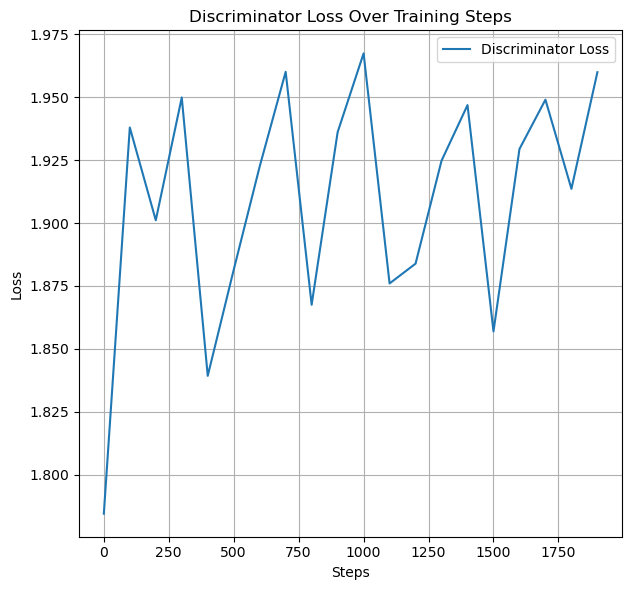

In [42]:
plt.figure(figsize=(12,6))

plt.subplot(1, 2, 1)
plt.plot(range(0, len(d_loss_history) * 10, 10), d_loss_history, label='Discriminator Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Discriminator Loss Over Training Steps')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

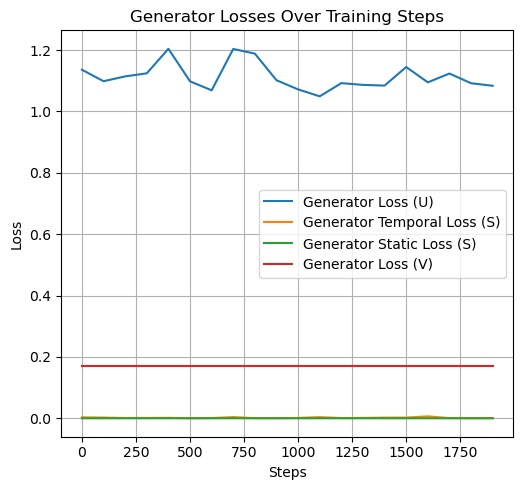

In [43]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 2)
plt.plot(range(0, len(g_loss_u_history) * 100, 100), g_loss_u_history, label='Generator Loss (U)')
plt.plot(range(0, len(g_loss_s_temp_history) * 100, 100), g_loss_s_temp_history, label='Generator Temporal Loss (S)')
plt.plot(range(0, len(g_loss_s_static_history) * 100, 100), g_loss_s_static_history, label='Generator Static Loss (S)')
plt.plot(range(0, len(g_loss_v_history) * 100, 100), g_loss_v_history, label='Generator Loss (V)')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Generator Losses Over Training Steps')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Generate Synthetic Data